In [1]:
from src.agent.langgraph_agent import ai_agent, external_kb_meta
from langchain_core.messages import AIMessage, HumanMessage

c:\Users\subin\.conda\envs\agentic.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2384.41it/s]


[ 2026-05-15 16:19:31,975 ]: INFO - 228 CrossEncoder - Use pytorch device: cpu


In [2]:
CONFIG = {'configurable': {'thread_id': "004"}}

In [3]:
user_input = "What is the current stock updates of Amazon?"

initial_state = {
        "messages": [HumanMessage(content=user_input)],
        "external_kb_meta": external_kb_meta
    }

In [4]:
response = ai_agent.invoke(initial_state, config=CONFIG)       #type: ignore
agent_message = response["messages"][-1].content
print(agent_message)

[ 2026-05-15 16:20:19,800 ]: INFO - 1025 _client - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
[ 2026-05-15 16:20:20,281 ]: INFO - 1025 _client - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


APIError: Tool choice is none, but model called a tool

In [4]:
!pip install -U wikipedia
!pip install -U langchain-community

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.5 MB 5.7 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 2.2 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 2.2 MB/s eta 0:00:01
   ---------------- ----------------------- 1.0/2.5 MB 1.3 MB/s eta 0:00:02
   ---------------------------- ----------- 1.8/2.5 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 2.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/548.1 kB ? eta -:--:--
   -------------------------------------- - 524.3/548.1 kB 3.4 MB/s eta 0:00:01
   -------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
embedchain 0.1.128 requires langchain-community<0.4.0,>=0.3.1, but you have langchain-community 0.4.1 which is incompatible.
embedchain 0.1.128 requires langchain-openai<0.3.0,>=0.2.1, but you have langchain-openai 0.3.28 which is incompatible.
langchain 0.3.26 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 1.4.0 which is incompatible.
langchain 0.3.26 requires langchain-text-splitters<1.0.0,>=0.3.8, but you have langchain-text-splitters 1.1.2 which is incompatible.
langchain-chroma 0.2.4 requires chromadb>=1.0.9, but you have chromadb 0.5.23 which is incompatible.
langchain-cohere 0.3.5 requires langchain-core<0.4.0,>=0.3.27, but you have langchain-core 1.4.0 which is incompatible.
langchain-experimental 0.3.4 requires langchain-community<0.4.0,>=0.3.0, but you have langchain-community 0.4.1 

In [14]:
import wikipedia

def wiki_tool(query: str):
    try:
        return wikipedia.summary(query, sentences=30)
    except Exception as e:
        return f"Wikipedia error: {str(e)}"

In [16]:
wiki_tool("Biography of Donald Trump")

'This bibliography of Donald Trump is a list of written and published works, by and about Donald Trump, the 45th and 47th president of the United States. Due to the sheer volume of books about Trump, the titles listed here are limited to non-fiction books about Trump or his presidency, published by notable authors and scholars. Tertiary sources (including textbooks and juvenile literature), satire, and self-published books are excluded.\nPrior to his 2016 presidential campaign, Trump was widely known by the American public and media establishment, and was already the focus of many books describing his life as a businessman, media personality, and politician. Biographer Michael D\'Antonio observed in Never Enough: Donald Trump and the Pursuit of Success (2015) that Trump "has been a topic of conversation in America for almost 40 years. No one in the world of business – not Bill Gates, Steve Jobs or Warren Buffett – has been as famous as Trump for as long." Almost one year after his inau

In [21]:
wikipedia.set_lang("en")

def wikipedia_tool(query):
    """
    Lightweight Wikipedia tool for LLMs.
    Returns only compact useful information.
    """

    try:
        # Search first
        results = wikipedia.search(query)

        if not results:
            return "No Wikipedia page found."

        # Take best match
        page_title = results[0]

        # Fetch page
        page = wikipedia.page(page_title, auto_suggest=False)

        # Compact response
        data = {
            "title": page.title,
            "summary": wikipedia.summary(page_title, sentences=10),
            "url": page.url,
            "sections": page.sections[:10],  # optional
        }

        return data

    except wikipedia.exceptions.DisambiguationError as e:
        return {
            "error": "DisambiguationError",
            "options": e.options[:5]
        }

    except Exception as e:
        return {"error": str(e)}


# Example
result = wikipedia_tool("Donald Trump")

print(result)

{'title': 'Donald Trump', 'summary': "Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman who is the 47th president of the United States. A member of the Republican Party, he served as the 45th president from 2017 to 2021.\nBorn into a wealthy New York City family, Trump graduated from the University of Pennsylvania in 1968 with a bachelor's degree in economics. He became the president of his family's real estate business in 1971, renamed it the Trump Organization, and began acquiring and building skyscrapers, hotels, casinos, and golf courses. He launched side ventures, many licensing the Trump name, and filed for six business bankruptcies in the 1990s and 2000s. From 2004 to 2015, he hosted the reality television show The Apprentice, bolstering his fame as a billionaire. Presenting himself as a political outsider, Trump won the 2016 presidential election against Democratic Party nominee Hillary Clinton.\nDuring his first presidency, Tr

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from src.agent.prompt import web_agent_prompt
from langchain_core.prompts import ChatPromptTemplate

c:\Users\subin\.conda\envs\agentic.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_groq import ChatGroq
web_agent_llm =  ChatGroq(model="openai/gpt-oss-20b", temperature=0.4)

In [3]:
from src.tools.tools import news_search, wiki_search, tavily_search

tools = [news_search, wiki_search, tavily_search]

web_agent_with_tools = web_agent_llm.bind_tools(tools)

chat_template = ChatPromptTemplate(
    [
        ("system", web_agent_prompt),
        ("human", "Question: {query}")
    ],
    input_variables=["query"]
)

chain = chat_template | web_agent_with_tools 

query = "Which team won the IPL match yesterday?"
web_results = chain.invoke({"query": query})

c:\Users\subin\.conda\envs\agentic.env\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


[ 2026-05-17 21:51:20,669 ]: INFO - 1025 _client - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [4]:
web_results

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Which team won the IPL match yesterday?" We need to determine which IPL match occurred yesterday (the day before the current date). The current date is 2026-05-17. So yesterday is 2026-05-16. We need to find out which IPL match took place on 2026-05-16 and which team won. We need to search. Use web search. Use tavily_search or news_search. Let\'s try news_search first.', 'tool_calls': [{'id': 'fc_5188c4de-5060-4cea-9904-afffba7c9da1', 'function': {'arguments': '{"query":"IPL match 2026-05-16 result"}', 'name': 'news_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 532, 'total_tokens': 664, 'completion_time': 0.137703701, 'prompt_time': 0.027358158, 'queue_time': 0.050994592, 'total_time': 0.165061859, 'completion_tokens_details': {'reasoning_tokens': 100}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3d587a02fb', 'service_tier': 

In [1]:
import os, sys
from typing import Optional
from typing_extensions import TypedDict, Literal, Annotated
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain.agents import create_agent
from langchain_core.runnables import RunnableConfig
from sentence_transformers import CrossEncoder
from pathlib import Path
from pydantic import BaseModel, Field
import google.generativeai as genai
from dotenv import load_dotenv
load_dotenv()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()
from src.logger.logging import logging
from src.exception.exception_handler import AppException
from utils.common import get_checkpointer
from src.tools.tools import retriever, tavily_search, news_search, wiki_search, weather_tool, stock_finance_tool
from src.agent.prompt import (router_system_prompt, rag_agent_system_prompt, web_agent_prompt,
                    answer_agent_prompt, vision_agent_prompt)


class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    query: str
    route_decision: Literal["rag", "web", "answer", "multimodal", "router", "none"]
    external_kb_meta: dict
    rag_results: str
    web_results: str
    uploaded_image: bool
    image_data: list
    intermediate_query: str

class RouteDecission(BaseModel):
    route: Literal["rag", "web", "answer", "multimodal", "none"]
    reply: str = Field(description="A reply message from LLM")

class RagVerdict(BaseModel):
    is_sufficient: bool = Field(..., description="True if retrieved information is sufficient to answer the user query, otherwise False")

class AnswerAgentResponse(BaseModel):
    intermediate_query: Optional[str] = Field(None, description="If the agent needs to ask a follow-up question, it will be stored in this variable, otherwise it will be None")
    final_answer: Optional[str] = Field(None, description="The final answer generated by the answer agent. It will be None if the agent needs to ask a follow-up question, otherwise it will contain the answer to the user query")


# Initialize LLMs
router_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0).with_structured_output(RouteDecission)
rag_agent_llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0).with_structured_output(RagVerdict)
web_agent_llm =  ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0.4)
answer_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7).with_structured_output(AnswerAgentResponse)
#meta-llama/llama-4-scout-17b-16e-instruct

# load reranker model for retriever tool
reranker_path = Path("models/bge-reranker-base")
reranker = CrossEncoder(str(reranker_path))

genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))                       #type: ignore                              
vision_llm = genai.GenerativeModel("gemini-2.5-pro")                       #type: ignore


# Node 1 : ROUTER NODE
def router_node(state: AgentState):
    """
    This node takes in the user query and the external knowledge base metadata (if available) and
    decides which node to route next based on the query.

    If the route is "none", it returns the router LLM gives the reply.
    Otherwise, it returns the query and the route decision.

    Args:
        state (AgentState): The current state of the agent.

    Returns:
        dict: A dictionary containing the route decision and the query.
    """
    
    if state.get("intermediate_query") is not None:
        query = state["intermediate_query"]
    else:
        query = str(state["messages"][-1].content)

    uploaded_image = state.get("uploaded_image", False)
    
    try:
        chat_template = ChatPromptTemplate(
            [
                ("system", router_system_prompt),
                ("human", "uploaded_image: {uploaded_image}\n\nexternal_kb_meta: {external_kb_meta}\n\nQuestion: {query}")
            ],
            input_variables=["external_kb_meta", "uploaded_image", "query"]
        )

        router = chat_template | router_llm 
        response : RouteDecission = router.invoke({"external_kb_meta": state["external_kb_meta"], 
                                                   "uploaded_image": uploaded_image,
                                                   "query": query
                                                    })                                                 # type: ignore

        if response.route=="none" and response.reply is not None:
            return {
                "route_decision": response.route, 
                "response": response.reply, 
                "messages": [AIMessage(content=response.reply)]
            }
    
        return {
            "route_decision": response.route, 
            "query": query
            }
    
    except Exception as e:
        logging.error("Error in the Router node: {e}, exc_info=True")
        raise AppException(e, sys)


# NODE 2 : RAG NODE
def rag_node(state: AgentState):
    """
    This node takes in the user query and the external knowledge base metadata (if available) and
    retrieves relevant documents from the external knowledge base stored in Pinecone database by
    performing RAG search.

    If the retrieval is successful, it then asks the RAG LLM to decide if the retrieved information is sufficient 
    to answer the user query.
    If the information is sufficient, it routes to the "answer" node, otherwise it routes to the "web" node.

    Args:
        state (AgentState): The current state of the agent.

    Returns:
        dict: A dictionary containing the route decision and the rag search retrieved documents.
    """

    docs = retriever.invoke({"query": state.get("query", "None"), 
                             "index_name": state["external_kb_meta"]["topic"], 
                             "reranker": reranker
                            })

    if docs.startswith('rag_error'):
        return {
            "route_decision": "web", 
            "rag_results": None
            }

    prompt_template = ChatPromptTemplate(
        [
            ("system", rag_agent_system_prompt),
            ("human", "Question: {query}\n\n retrieved_docs: {retreived_docs}")
        ],
        input_variables=["query", "docs"]
    )

    rag = prompt_template | rag_agent_llm
    try:
        verdict: RagVerdict = rag.invoke({"query": state["query"], "retreived_docs": docs})                          # type: ignore
        # Decide next route
        if verdict.is_sufficient:
            return {
                "route_decision": "answer", 
                "rag_results": docs
                }
        else:
            response = f"""Sufficient information is NOT available in the retrieved documents. However, here are the retrieved documents 
            that might be useful for answering the question after performing a web search:\n {docs}"""
            return {
                "route_decision": "web", 
                "rag_results": response
            }
        
    except Exception as e:
        logging.error(f"Error in rag node: {e}", exc_info=True)
        return {
            "rag_results": "Error during RAG search!", 
            "route_decision": "web"
            }


# NODE 3: WEB NODE
def web_node(state: AgentState):
    """
    This node takes in the user query and performs a web search using the tools given.
    After the web search, it always redirects to the answer agent. The web agent is based on ReAct framework.

    Args:
        state (AgentState): The current state of the agent.

    Returns:
        dict: A dictionary containing the web search results and the route decision.
    """

    web_react_agent = create_agent(
        model = web_agent_llm,
        tools = [tavily_search, news_search, wiki_search, weather_tool, stock_finance_tool],
        system_prompt = web_agent_prompt
    )

    config = RunnableConfig({
        "recursion_limit": 10
        })
    
    try:
        response = web_react_agent.invoke(
            {"messages": [{"role": "user", "content": state["query"]}]},
            config=config
        )

        return {
            "web_results": response["messages"][-1].content, 
            "route_decision": "answer"
            }
    
    except Exception as e:
        logging.error(f"Error in web node: {e}", exc_info=True)
        return {
            "web_results": "Error during web search!", 
            "route_decision": "answer"
            }


# NODE 4: ANSWER NODE
def answer_node(state: AgentState):
    """
    This node takes in the user query and the results from the RAG and WEB nodes and generates the final answer 
    based on the context and chat history. 
    If the agent determines that it needs to ask a follow-up question, it routes back to the router node.

    Args:
        state (AgentState): The current state of the agent.

    Returns:
        dict: A dictionary containing the final answer and the next route decision.
    """
    rag_results = state.get("rag_results", "None")
    web_results = state.get("web_results", None)
    chat_history = state["messages"][-15:]
    parser = PydanticOutputParser(pydantic_object=AnswerAgentResponse)

    chat_template = ChatPromptTemplate(
    [
        ("system", answer_agent_prompt),
        ("human", "Context: {rag_results}\n\n Web Results: {web_results}\n\n Chat History: {chat_history}\n\n Question: {query}")
    ],
    input_variables=["rag_results", "web_results", "chat_history", "query"],
    partial_variables={"format_instructions": parser.get_format_instructions()}
    )
    
    chain = chat_template | answer_llm 
    try:
        response : AnswerAgentResponse=chain.invoke({"query": state["query"], 
                                                     "rag_results": rag_results, 
                                                     "web_results": web_results, 
                                                     "chat_history": chat_history
                                                    })                                          # type: ignore
        
        if response.intermediate_query is not None:
            next_route = "router"
            return {
                "route_decision": next_route, 
                "intermediate_query": response.intermediate_query
                }
        else:
            return{
                "route_decision": "none", 
                "web_results": [],
                "messages": [AIMessage(content=response.final_answer)]
                }
        
    except Exception as e:
        logging.error(f"Error in answer node: {e}", exc_info=True)
        return {"messages": [AIMessage(content=f"I apologize, but I encountered an error!! Please try again later.")]}
    

# NODE 5: MULTIMODAL NODE
def multimodal_node(state: AgentState):
    try:
        image_data = state.get("image_data", None)

        if image_data is not None:
            response = vision_llm.generate_content([vision_agent_prompt, image_data[0]])            # type: ignore
            return {"response": response.text, "messages": [AIMessage(content=response.text)]}
    
    except Exception as e:
        logging.error(f"Error in multimodal node: {e}", exc_info=True)
        return {"messages": [AIMessage(content=f"I apologize, but I encountered an error!! Please try again later.")]}


# CONDITIONAL FUNCTIONS FOR GRAPH EDGES
def from_router(state) -> Literal["rag", "web", "answer", "multimodal", "none"]:        
    """
    This function takes in the current state of the agent and returns the route decision made by the router node.
    If the route decision is 'router', it raises a ValueError as the router node cannot route to itself.
    """
    if state["route_decision"] == "router":
        raise ValueError("route_decision from router node cannot be 'router' again")
    return state["route_decision"]

def after_rag(state) -> Literal["web_agent", "answer_agent"]:
    """
    This function takes in the current state of the agent and returns the next node to be visited after the RAG node.
    If the route decision is 'web', it returns 'web_agent', otherwise it returns 'answer_agent'.
    """
    if state["route_decision"] == "web":
        return "web_agent"
    else:
        return "answer_agent"

def from_answer(state) -> Literal["follow_up", "none"]:
    """
    This function takes in the current state of the agent and returns the next node to be visited after the answer node.
    If the route decision is 'router', it returns 'follow_up', otherwise it returns 'none'.
    """
    if state["route_decision"] == "router":
        return "follow_up"
    else:
        return "none"
    

# BUILD GRAPH WORKFLOW :
graph = StateGraph(AgentState)

graph.add_node("router", router_node)
graph.add_node("rag_agent", rag_node)
graph.add_node("web_agent", web_node)
graph.add_node("answer_agent", answer_node)
graph.add_node("multimodal_agent", multimodal_node)

graph.set_entry_point("router")
graph.add_conditional_edges(
    "router",
    from_router,
    {
        "rag": "rag_agent",
        "web": "web_agent",
        "answer": "answer_agent",
        "multimodal": "multimodal_agent",
        "none": END
    }
)
graph.add_conditional_edges(
    "rag_agent",
    after_rag,
    {
        "web_agent": "web_agent",
        "answer_agent": "answer_agent"
    }
)
graph.add_edge("web_agent", "answer_agent")
graph.add_edge("multimodal_agent", END)
graph.add_conditional_edges(
    "answer_agent",
    from_answer,
    {
        "follow_up": "router",
        "none": END
    })

# FINALIZE AGENT
checkpointer = get_checkpointer()
ai_agent = graph.compile(checkpointer=checkpointer)

c:\Users\subin\.conda\envs\agentic.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1638.77it/s]


[ 2026-05-18 22:03:23,535 ]: INFO - 228 CrossEncoder - Use pytorch device: cpu


In [3]:
!pip install ipython

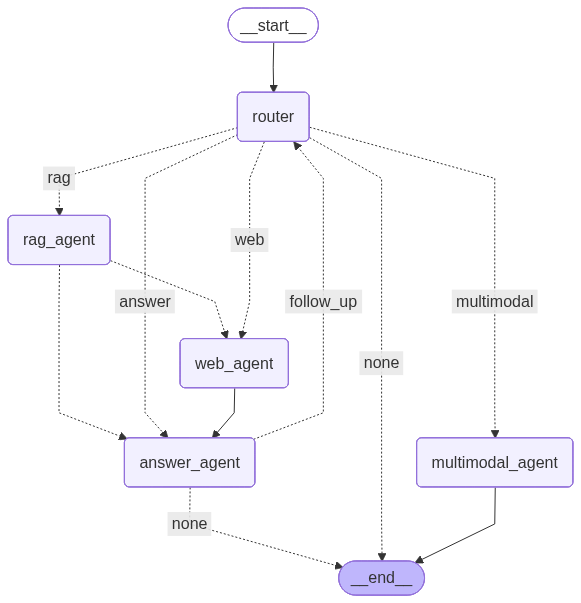

In [3]:
from IPython.display import Image
Image(ai_agent.get_graph().draw_mermaid_png())